# Clustering Case Study: Customer Segmentation with K-Means -  Tier 3
***
This case study is based on [this blog post](http://blog.yhat.com/posts/customer-segmentation-using-python.html) by the `yhat` blog. Please feel free to refer to the post for additional information, and solutions.

Structure of the mini-project:

1. **Sourcing and loading**
    * Load the data
    * Explore the data


2. **Cleaning, transforming and visualizing**
    * Data Wrangling: Exercise Set 1
        - Creating a matrix with a binary indicator for whether they responded to a given offer
        - Ensure that in doing so, NAN values are dealt with appropriately
    

3. **Modelling** 
    * K-Means clustering: Exercise Sets 2 and 3
        - Choosing K: The Elbow method
        - Choosing K: The Silhouette method
        - Choosing K: The Gap statistic method
    
    * Visualizing clusters with PCA: Exercise Sets 4 and 5


4. **Conclusions and next steps**
    * Conclusions
    * Other clustering algorithms (Exercise Set 6)

In [15]:
%matplotlib inline
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

# Setup Seaborn
sns.set_style("whitegrid")
sns.set_context("poster")

## 1. Sourcing and loading
### 1a. Load the data
The dataset contains information on marketing newsletters/e-mail campaigns (e-mail offers sent to customers) and transaction level data from customers. The transactional data shows which offer customers responded to, and what the customer ended up buying. The data is presented as an Excel workbook containing two worksheets. Each worksheet contains a different dataset.

In [16]:
df_offers = pd.read_excel("./WineKMC.xlsx", sheet_name=0)

/Users/Allison/Code/.venv/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


### 1b. Explore the data

In [17]:
df_offers.columns = ["offer_id", "campaign", "varietal", "min_qty", "discount", "origin", "past_peak"]
df_offers.head()

,offer_id,campaign,varietal,min_qty,discount,origin,past_peak
0,1,January,Malbec,72,56,France,False
1,2,January,Pinot Noir,72,17,France,False
2,3,February,Espumante,144,32,Oregon,True
3,4,February,Champagne,72,48,France,True
4,5,February,Cabernet Sauvignon,144,44,New Zealand,True


We see that the first dataset contains information about each offer such as the month it is in effect and several attributes about the wine that the offer refers to: the variety, minimum quantity, discount, country of origin and whether or not it is past peak. The second dataset in the second worksheet contains transactional data -- which offer each customer responded to.

In [18]:
df_transactions = pd.read_excel("./WineKMC.xlsx", sheet_name=1)
df_transactions.columns = ["customer_name", "offer_id"]
df_transactions['n'] = 1
df_transactions.head()

/Users/Allison/Code/.venv/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,customer_name,offer_id,n
0,Smith,2,1
1,Smith,24,1
2,Johnson,17,1
3,Johnson,24,1
4,Johnson,26,1


## 2. Cleaning, transforming and visualizing
### 2a. Data Wrangling

We're trying to learn more about how our customers behave, so we can use their behavior (whether or not they purchased something based on an offer) as a way to group similar minded customers together. We can then study those groups to look for patterns and trends which can help us formulate future offers.

The first thing we need is a way to compare customers. To do this, we're going to create a matrix that contains each customer and a 0/1 indicator for whether or not they responded to a given offer. 

<div class="span5 alert alert-info">
<h3>Checkup Exercise Set I</h3>

<p><b>Exercise:</b> Create a data frame where each row has the following columns (Use the pandas [`merge`](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.merge.html) and [`pivot_table`](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.pivot_table.html) functions for this purpose):
<ul>
<li> customer_name
<li> One column for each offer, with a 1 if the customer responded to the offer
</ul>
<p>Make sure you also deal with any weird values such as `NaN`. Read the documentation to develop your solution.</p>
</div>

In [ ]:
#your turn
df_merge = pd.merge(df_offers, df_transactions)
df_pivot = df_merge.pivot_table(index='customer_name', columns='offer_id', values='n', fill_value=0).astype(int)
df_pivot = df_pivot.astype(int)

print(df_merge.head(), '\n')
print('df_merge shape:', df_merge.shape, '\n')
# print(df_merge.info(show_counts=True))
# print(df_merge.isnull().sum())
# for col in ['offer_id', 'campaign', 'varietal', 'min_qty', 'discount', 'origin', 'past_peak']:
# 	print(f"{col}: {df_merge[col].unique()}")
print(df_pivot.head(), '\n')
print('df_pivot shape', df_pivot.shape)

   offer_id campaign varietal  min_qty  discount  origin  past_peak  \
0         1  January   Malbec       72        56  France      False   
1         1  January   Malbec       72        56  France      False   
2         1  January   Malbec       72        56  France      False   
3         1  January   Malbec       72        56  France      False   
4         1  January   Malbec       72        56  France      False   

  customer_name  n  
0        Thomas  1  
1       Jackson  1  
2      Mitchell  1  
3      Peterson  1  
4          Wood  1   

df_merge shape: (324, 9) 

number of unique customers: 100
offer_id       1   2   3   4   5   6   7   8   9   10  ...  23  24  25  26  \
customer_name                                          ...                   
Adams           0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   
Allen           0   0   0   0   0   0   0   0   1   0  ...   0   0   0   0   
Anderson        0   0   0   0   0   0   0   0   0   0  ...   0   1   0   1

## 3. Modelling 
### 3a. K-Means Clustering

Recall that in K-Means Clustering we want to *maximize* the distance between centroids and *minimize* the distance between data points and the respective centroid for the cluster they are in. True evaluation for unsupervised learning would require labeled data; however, we can use a variety of intuitive metrics to try to pick the number of clusters K. We will introduce two methods: the Elbow method, the Silhouette method and the gap statistic.

#### 3ai. Choosing K: The Elbow Sum-of-Squares Method

The first method looks at the sum-of-squares error in each cluster against $K$. We compute the distance from each data point to the center of the cluster (centroid) to which the data point was assigned. 

$$SS = \sum_k \sum_{x_i \in C_k} \sum_{x_j \in C_k} \left( x_i - x_j \right)^2 = \sum_k \sum_{x_i \in C_k} \left( x_i - \mu_k \right)^2$$

where $x_i$ is a point, $C_k$ represents cluster $k$ and $\mu_k$ is the centroid for cluster $k$. We can plot SS vs. $K$ and choose the *elbow point* in the plot as the best value for $K$. The elbow point is the point at which the plot starts descending much more slowly. 

**Hint:** the Elbow Method is discussed in part 2 of the Harvard Clustering lecture. 

### Checkup Exercise Set II

**Exercise:**

- What values of $SS$ do you believe represent better clusterings? Why?
- Create a NumPy matrix `x_cols` with only the columns representing the offers (i.e. the 0/1 columns).
- Write code that applies the
  [`KMeans`](http://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)
  clustering method from scikit-learn to this matrix.
- Construct a plot showing $SS$ for each $K$ and pick $K$ using this plot.  
  For simplicity, test $2 \le K \le 10$.
- Make a bar chart showing the number of points in each cluster for k-means under the best $K$.
- What challenges did you experience using the Elbow method to pick $K$?
  - **Answer: There isn't a strong elbow in this inertia plot, so it's difficult to choose K. K=3 looks like the best choice to me since the slope of the line appears to decrease after that, but the evidence is not conclusive.**

In [20]:
# your turn
# create Numpy array with values from pivot table
x_cols = df_pivot.to_numpy()
print(x_cols[:5])

[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0]]


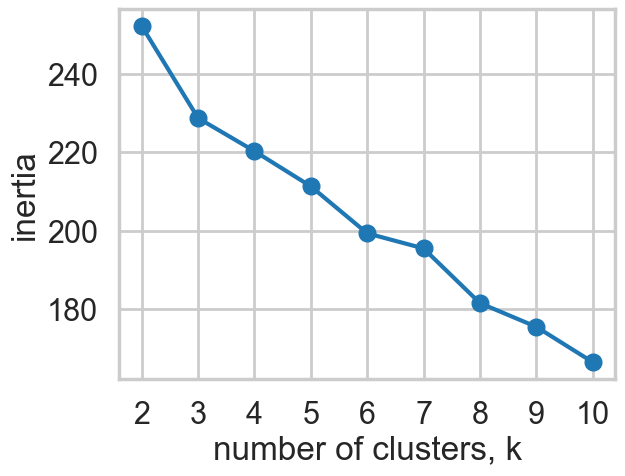

In [21]:
# apply KMeans to Numpy array
from sklearn.cluster import KMeans

ks = range(2, 11)
inertias = []

for k in ks:
    # Create a KMeans instance with k clusters: model
    kmeans = KMeans(n_clusters=k, random_state=42)
    
    # Fit model to samples
    kmeans.fit(x_cols)
    
    # Append the inertia to the list of inertias
    inertias.append(kmeans.inertia_)
    
# Plot ks vs inertias
plt.plot(ks, inertias, '-o')
plt.xlabel('number of clusters, k')
plt.ylabel('inertia')
plt.xticks(ks)
plt.show()

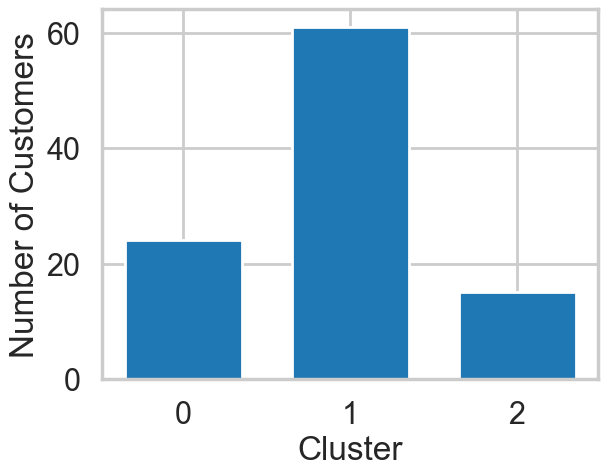

In [30]:
# Make a bar chart showing the number of points in each cluster
import numpy as np

kmeans3 = KMeans(n_clusters=3, random_state=42)
kmeans3_labels = kmeans3.fit_predict(x_cols)    
plt.hist(kmeans3_labels, bins=np.arange(4), align='left', rwidth=0.7)
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.xticks(range(3))
plt.show()


#### 3aii. Choosing K: The Silhouette Method

There exists another method that measures how well each datapoint $x_i$ "fits" its assigned cluster *and also* how poorly it fits into other clusters. This is a different way of looking at the same objective. Denote $a_{x_i}$ as the *average* distance from $x_i$ to all other points within its own cluster $k$. The lower the value, the better. On the other hand $b_{x_i}$ is the minimum average distance from $x_i$ to points in a different cluster, minimized over clusters. That is, compute separately for each cluster the average distance from $x_i$ to the points within that cluster, and then take the minimum. The silhouette $s(x_i)$ is defined as

$$s(x_i) = \frac{b_{x_i} - a_{x_i}}{\max{\left( a_{x_i}, b_{x_i}\right)}}$$

The silhouette score is computed on *every datapoint in every cluster*. The silhouette score ranges from -1 (a poor clustering) to +1 (a very dense clustering) with 0 denoting the situation where clusters overlap. Some criteria for the silhouette coefficient is provided in the table below.

<pre>

| Range       | Interpretation                                |
|-------------|-----------------------------------------------|
| 0.71 - 1.0  | A strong structure has been found.            |
| 0.51 - 0.7  | A reasonable structure has been found.        |
| 0.26 - 0.5  | The structure is weak and could be artificial.|
| < 0.25      | No substantial structure has been found.      |

</pre>
Source: http://www.stat.berkeley.edu/~spector/s133/Clus.html

**Hint**: Scikit-learn provides a function to compute this for us (phew!) called [`sklearn.metrics.silhouette_score`](http://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html). Take a look at [this article](http://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html) on picking $K$ in scikit-learn, as it will help you in the next exercise set.

<div class="span5 alert alert-info">
<h3>Checkup Exercise Set III</h3>

<p><b>Exercise:</b> Using the documentation for the `silhouette_score` function above, construct a series of silhouette plots like the ones in the article linked above.</p>

<p><b>Exercise:</b> Compute the average silhouette score for each $K$ and plot it. What $K$ does the plot suggest we should choose? Does it differ from what we found using the Elbow method?</p>

<p><b>Answer: K=3 appears to be the best clustering solution. In the elbow plot K=3 also appeared to be a reasonable choice, but had weak evidence to support it. Combining the silhouette analysis with the elbow plot provides strong support for selecting K=3. 

Although the silhouette score is slightly higher for K=9 and K=10, the increase is small and the overall scores are low, suggesting weak cluster separation. Choosing a larger K risks overfitting and results in clusters that are less interpretable. K=3 provides a simpler, more meaningful segmentation that balances interpretability and model performance and will make sense when visualized in the PCA plot below.</b></p>
</div>

n_clusters = 2 silhouette score: 0.08332686363764968
n_clusters = 3 silhouette score: 0.1107183912025193
n_clusters = 4 silhouette score: 0.08977353182101117
n_clusters = 5 silhouette score: 0.09221542793738659
n_clusters = 6 silhouette score: 0.10217589264135302
n_clusters = 7 silhouette score: 0.07250151832510414
n_clusters = 8 silhouette score: 0.10923364902075393
n_clusters = 9 silhouette score: 0.11169203623746345
n_clusters = 10 silhouette score: 0.12061167766824962


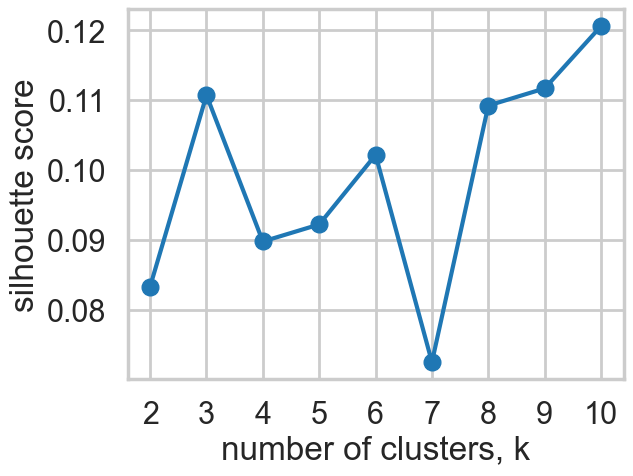

In [23]:
# Your turn.
from sklearn.metrics import silhouette_score

sil_scores = []
for n_clusters in range(2, 11):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    # Fit and predict your k-Means object
    preds = kmeans.fit_predict(x_cols)
    score = silhouette_score(x_cols, preds, metric='euclidean')
    sil_scores.append(score)
    print ('n_clusters =', n_clusters, 'silhouette score:', score)

# Plot ks vs silhouette scores
plt.plot(ks, sil_scores, '-o')
plt.xlabel('number of clusters, k')
plt.ylabel('silhouette score')
plt.xticks(ks)
plt.show()
    

#### Aside: Choosing $K$ when we Have Labels

Unsupervised learning expects that we do not have the labels. In some situations, we may wish to cluster data that is labeled. Computing the optimal number of clusters is much easier if we have access to labels. There are several methods available. We will not go into the math or details since it is rare to have access to the labels, but we provide the names and references of these measures.

* Adjusted Rand Index
* Mutual Information
* V-Measure
* Fowlkes–Mallows index

**Hint:** See [this article](http://scikit-learn.org/stable/modules/clustering.html) for more information about these metrics.

#### 3aiii.  Choosing $K$: The Gap Statistic

There is one last method worth covering for picking $K$, the so-called Gap statistic. The computation for the gap statistic builds on the sum-of-squares established in the Elbow method discussion, and compares it to the sum-of-squares of a "null distribution," that is, a random set of points with no clustering. The estimate for the optimal number of clusters $K$ is the value for which $\log{SS}$ falls the farthest below that of the reference distribution:

$$G_k = E_n^*\{\log SS_k\} - \log SS_k$$

In other words a good clustering yields a much larger difference between the reference distribution and the clustered data. The reference distribution is a Monte Carlo (randomization) procedure that constructs $B$ random distributions of points within the bounding box (limits) of the original data and then applies K-means to this synthetic distribution of data points.. $E_n^*\{\log SS_k\}$ is just the average $SS_k$ over all $B$ replicates. We then compute the standard deviation $\sigma_{SS}$ of the values of $SS_k$ computed from the $B$ replicates of the reference distribution and compute

$$s_k = \sqrt{1+1/B}\sigma_{SS}$$

Finally, we choose $K=k$ such that $G_k \geq G_{k+1} - s_{k+1}$.

### 3b. Visualizing Clusters using PCA

How do we visualize clusters? If we only had two features, we could likely plot the data as is. But we have 100 data points each containing 32 features (dimensions). Principal Component Analysis (PCA) will help us reduce the dimensionality of our data from 32 to something lower. For a visualization on the coordinate plane, we will use 2 dimensions. In this exercise, we're going to use it to transform our multi-dimensional dataset into a 2 dimensional dataset.

This is only one use of PCA for dimension reduction. We can also use PCA when we want to perform regression but we have a set of highly correlated variables. PCA untangles these correlations into a smaller number of features/predictors all of which are orthogonal (not correlated). PCA is also used to reduce a large set of variables into a much smaller one.

**Hint:** PCA was discussed in the previous subunit. If you need help with it, consult [this useful article](https://towardsdatascience.com/a-one-stop-shop-for-principal-component-analysis-5582fb7e0a9c) and [this visual explanation](http://setosa.io/ev/principal-component-analysis/). 

### Checkup Exercise Set IV

**Exercise:** Use PCA to plot your clusters:

- Use scikit-learn’s [`PCA`](http://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) function to reduce the dimensionality of your clustering data to 2 components.
- Create a DataFrame with the following fields:
  - customer name  
  - cluster ID the customer belongs to  
  - the two PCA components (label them `x` and `y`)
- Plot a scatterplot of the `x` vs `y` columns.
- Color-code points differently based on cluster ID.
- How do the clusters look?
  - **On the PCA plot it looks like there is some overlap between clusters 1 and 2.** 
- Based on what you see, what seems to be the best value for \(K\)? Moreover, which method of choosing \(K\) seems to have produced the optimal result visually?
  - **The best values for K appears to be 3. Both the elbow and silhouette methods supported this choice and it looks appropriate on the PCA plot, where there do appear to be 3 weakly separate groups.**

In [24]:
#your turn
# - Use scikit-learn’s PCA function to reduce the dimensionality of data to 2 components.
from sklearn.decomposition import PCA
pca_model = PCA(n_components=2)
pca_model.fit(x_cols)
x_transformed = pca_model.transform(x_cols)
print(x_transformed[0:5])

[[ 1.00757996  0.10821467]
 [-0.28753924  0.04471451]
 [-0.39203204  1.03839141]
 [ 0.69947727 -0.02254222]
 [ 0.08818322 -0.47169543]]


In [25]:
# - Create a DataFrame with the following fields:
#   - customer name  
#   - cluster ID the customer belongs to  
#   - the two PCA components (label them `x` and `y`)
pca_df = pd.DataFrame(data=x_transformed, 
                      columns=['x', 'y'], 
                      index=df_pivot.index)
pca_df['customer_name'] = pca_df.index
pca_df = pca_df.reset_index(drop=True)

pca_df.head()


,x,y,customer_name
0,1.007580,0.108215,Adams
1,-0.287539,0.044715,Allen
2,-0.392032,1.038391,Anderson
3,0.699477,-0.022542,Bailey
4,0.088183,-0.471695,Baker


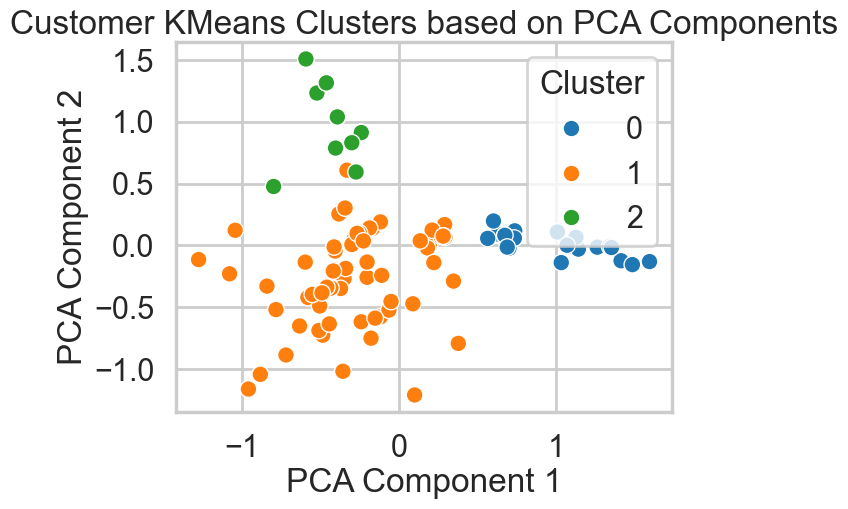

In [35]:
# - Plot a scatterplot of the `x` vs `y` columns.
# - Color-code points differently based on cluster ID.
kmeans3 = KMeans(n_clusters=3, random_state=42)
clusterID = kmeans3.fit_predict(x_cols)
pca_df['clusterID'] = clusterID
import seaborn as sns
sns.scatterplot(
    data=pca_df,
    x='x', y='y',
    hue='clusterID',
    palette='tab10'
)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Customer KMeans Clusters based on PCA Components')
plt.legend(title='Cluster')
plt.show()

What we've done is we've taken those columns of 0/1 indicator variables, and we've transformed them into a 2-D dataset. We took one column and arbitrarily called it `x` and then called the other `y`. Now we can throw each point into a scatterplot. We color coded each point based on it's cluster so it's easier to see them.

### Checkup Exercise Set IV
**Exercise:** Now look at both the original raw data about the offers and transactions *and* the fitted clusters. Tell a story about the clusters in the context of the original data. For example, do the clusters correspond to wine variants or something else interesting?

#### Summary of Observtions by Feature ####

**Brief Overview:** The clustering reveals three distinct promotional profiles. Cluster 0 is characterized by smaller minimum quantities, high (but not extreme) discounts, and a strong emphasis on Sparkling wines promoted primarily during Holiday and Spring campaigns. Cluster 1 represents large-volume offers with very high discounts, a heavy concentration of Sparkling wines, and campaigns spread across Fall and Summer, suggesting aggressive, clearance-style promotions. In contrast, Cluster 2 is dominated by Red wines, Old World origins, and Fall campaigns, with more moderate and evenly distributed discounts and flexible minimum quantities. Across all clusters, the majority of products have not passed their peak, indicating that discounting strategies are not primarily driven by aging concerns.

**Detailed Results**

**1. Campaign**  
Campaign months were binned into retail-oriented seasons: Spring, Summer, Fall, Holiday, and Winter.  
- In **Cluster 0**, Holiday (~44%) and Spring (~41%) campaigns are most prevalent, while these campaigns are minimally represented in **Cluster 2** (~0% and ~3%, respectively).  
- **Cluster 1** is most strongly associated with Fall (29%) and Summer (28%) campaigns, followed by Holiday and Winter, both at approximately 16%.  
- The single highest campaign concentration across all clusters is the **Fall campaign in Cluster 2**, accounting for approximately 63%.

**2. Varietal**  
Varietals were grouped into three categories: Red, White, and Sparkling.  
- **Cluster 0** is primarily composed of Sparkling wines (~48%), followed by Red (~31%) and White (~21%).  
- **Cluster 1** shows an even stronger emphasis on Sparkling wines (~60%), with Red comprising ~32% and White minimally represented (~8%).  
- **Cluster 2** is overwhelmingly dominated by Red varietals (~93%), with very limited representation of White (~3%) and Sparkling (~5%).

**3. Minimum Quantity**  
- **Cluster 0** consists exclusively of a minimum quantity of 6.  
- **Cluster 1** is dominated by a minimum quantity of 72 (~59%), followed by 144 (~22%), 6 (~13%), and 12 (~7%).  
- **Cluster 2** exhibits a relatively balanced distribution across minimum quantities of 6 (~30%), 12 (~18%), 72 (~23%), and 144 (~30%).

**4. Discount**  
Discounts were grouped into Low, Medium, High, and Very High bins, revealing distinct patterns across clusters.  
- **Cluster 0** is dominated by High discounts (~54%), followed by Medium discounts (~15%), with no Low discounts represented.  
- **Cluster 1** is primarily characterized by Very High discounts (~50%), followed by High discounts (~35%), while Medium and Low discounts each account for less than 10%.  
- **Cluster 2** shows a more even distribution across discount levels, with Medium (~33%) and Very High (~30%) being the most common.

**5. Origin**  
Countries of origin were categorized as New World or Old World.  
- **Clusters 0 and 1** display relatively balanced distributions between New World and Old World wines (Cluster 0: ~56% vs. ~44%; Cluster 1: ~48% vs. ~52%).  
- In contrast, **Cluster 2** is more heavily weighted toward Old World wines (~65%), with New World wines comprising only ~35%.

**6. Past Peak**  
- Across all clusters, the majority of observations are classified as **“False”** for past peak status: approximately 83% in Cluster 0, 79% in Cluster 1, and 100% in Cluster 2.












In [ ]:
# merge original data set with cluster assignments
df_merge_clustered = pd.merge(df_merge, pca_df[['customer_name', 'clusterID']], on='customer_name', indicator=True, validate='m:1')
print(df_merge_clustered.head())

   offer_id campaign varietal  min_qty  discount  origin  past_peak  \
0         1  January   Malbec       72        56  France      False   
1         1  January   Malbec       72        56  France      False   
2         1  January   Malbec       72        56  France      False   
3         1  January   Malbec       72        56  France      False   
4         1  January   Malbec       72        56  France      False   

  customer_name  n  clusterID _merge  
0        Thomas  1          1   both  
1       Jackson  1          1   both  
2      Mitchell  1          1   both  
3      Peterson  1          2   both  
4          Wood  1          1   both  
(324, 11)


In [ ]:
# inspect df_merge_clustered dataframe
  
print(df_merge_clustered['clusterID'].value_counts())
print(df_merge_clustered['_merge'].value_counts())
for col in ['offer_id', 'campaign', 'varietal', 'min_qty', 'discount', 'origin', 'past_peak']:
	print(f"{col}: {df_merge_clustered[col].unique()}")



clusterID
1    213
0     71
2     40
Name: count, dtype: int64
_merge
both          324
left_only       0
right_only      0
Name: count, dtype: int64
offer_id: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32]
campaign: ['January' 'February' 'March' 'April' 'May' 'June' 'July' 'August'
 'September' 'October' 'November' 'December']
varietal: ['Malbec' 'Pinot Noir' 'Espumante' 'Champagne' 'Cabernet Sauvignon'
 'Prosecco' 'Chardonnay' 'Merlot' 'Pinot Grigio']
min_qty: [ 72 144   6  12]
discount: [56 17 32 48 44 86 40 45 57 52 85 83 43 64 19 88 47 50 66 82 63 39 34 59
 87 54 89]
origin: ['France' 'Oregon' 'New Zealand' 'Chile' 'Australia' 'South Africa'
 'California' 'Italy' 'Germany']
past_peak: [False  True]


In [ ]:
# bin discounts for smaller more interpretable groups

df_merge_clustered['discount_bin'] = pd.cut(
    df_merge_clustered['discount'],
    bins=[0, 30, 45, 60, 100],
    labels=['Low', 'Medium', 'High', 'Very High'],
    right=False
)

pd.crosstab(df_merge_clustered['clusterID'], df_merge_clustered['discount_bin'], normalize='index').transpose()


clusterID,0,1,2
discount_bin,,,
Low,0.000000,0.046948,0.150
Medium,0.253521,0.098592,0.325
High,0.535211,0.352113,0.225
Very High,0.211268,0.502347,0.300


In [60]:
# cross-tabulate campaigns by month

pd.crosstab(df_merge_clustered['clusterID'], df_merge_clustered['campaign'], normalize='index').transpose()


clusterID,0,1,2
campaign,,,
April,0.000000,0.075117,0.025
August,0.000000,0.145540,0.000
December,0.225352,0.126761,0.000
February,0.000000,0.103286,0.000
January,0.000000,0.061033,0.175
July,0.154930,0.037559,0.175
June,0.000000,0.093897,0.000
March,0.323944,0.131455,0.000
May,0.084507,0.084507,0.000


In [72]:
# bin campaigns by retail-oriented season 

season_map_retail = {
    'November': 'Holiday',
    'December': 'Holiday',
    'January': 'Winter',
    'February': 'Winter',
    'March': 'Spring',
    'April': 'Spring',
    'May': 'Spring',
    'June': 'Summer',
    'July': 'Summer',
    'August': 'Summer',
    'September': 'Fall',
    'October': 'Fall',
}

df_merge_clustered['season_retail'] = df_merge_clustered['campaign'].map(season_map_retail)
pd.crosstab(df_merge_clustered['clusterID'],
            df_merge_clustered['season_retail'], normalize='index').transpose()

clusterID,0,1,2
season_retail,,,
Fall,0.000000,0.103286,0.625
Holiday,0.436620,0.164319,0.000
Spring,0.408451,0.291080,0.025
Summer,0.154930,0.276995,0.175
Winter,0.000000,0.164319,0.175


In [ ]:
# bin campaigns by meteorological season
season_map = {
    'December': 'Winter',
    'January': 'Winter',
    'February': 'Winter',
    'March': 'Spring',
    'April': 'Spring',
    'May': 'Spring',
    'June': 'Summer',
    'July': 'Summer',
    'August': 'Summer',
    'September': 'Fall',
    'October': 'Fall',
    'November': 'Fall'
}

df_merge_clustered['season'] = df_merge_clustered['campaign'].map(season_map)

pd.crosstab(df_merge_clustered['clusterID'], df_merge_clustered['season'], normalize='index').transpose()

clusterID,0,1,2
season,,,
Fall,0.211268,0.140845,0.625
Spring,0.408451,0.291080,0.025
Summer,0.154930,0.276995,0.175
Winter,0.225352,0.291080,0.175


In [65]:
# inspect varietals by cluster
pd.crosstab(df_merge_clustered['clusterID'], df_merge_clustered['varietal'], normalize='index').transpose()

clusterID,0,1,2
varietal,,,
Cabernet Sauvignon,0.000000,0.150235,0.000
Champagne,0.000000,0.375587,0.025
Chardonnay,0.000000,0.065728,0.025
Espumante,0.309859,0.084507,0.000
Malbec,0.225352,0.070423,0.025
Merlot,0.084507,0.065728,0.000
Pinot Grigio,0.211268,0.009390,0.000
Pinot Noir,0.000000,0.037559,0.900
Prosecco,0.169014,0.140845,0.025


In [67]:
# bin varietals into red, white, sparkling
wine_type_map = {
        'Malbec': 'Red',
    'Pinot Noir': 'Red',
    'Cabernet Sauvignon': 'Red',
    'Merlot': 'Red',
    'Chardonnay': 'White',
    'Pinot Grigio': 'White',
    'Champagne': 'Sparkling',
    'Prosecco': 'Sparkling',
    'Espumante': 'Sparkling'
}
df_merge_clustered['wine_type'] = df_merge_clustered['varietal'].map(wine_type_map)

pd.crosstab(df_merge_clustered['clusterID'],
                               df_merge_clustered['wine_type'], normalize='index').transpose()


clusterID,0,1,2
wine_type,,,
Red,0.309859,0.323944,0.925
Sparkling,0.478873,0.600939,0.050
White,0.211268,0.075117,0.025


In [68]:
# cross-tabulate origin by cluster
pd.crosstab(df_merge_clustered['clusterID'],
             df_merge_clustered['origin'],
               normalize='index').transpose()

clusterID,0,1,2
origin,,,
Australia,0.169014,0.075117,0.275
California,0.000000,0.070423,0.025
Chile,0.084507,0.145540,0.000
France,0.436620,0.422535,0.175
Germany,0.000000,0.042254,0.175
Italy,0.000000,0.056338,0.300
New Zealand,0.000000,0.056338,0.025
Oregon,0.154930,0.070423,0.000
South Africa,0.154930,0.061033,0.025


In [69]:
# bin origin into Old World vs New World
origin_map = {
    'France': 'Old World',
    'Italy': 'Old World',
    'Germany': 'Old World',
    'California': 'New World',  
    'Oregon': 'New World',
    'Chile': 'New World',
    'Australia': 'New World',
    'New Zealand': 'New World',
    'South Africa': 'New World'
}
df_merge_clustered['origin_bin'] = df_merge_clustered['origin'].map(origin_map)
pd.crosstab(df_merge_clustered['clusterID'],
             df_merge_clustered['origin_bin'],
               normalize='index').transpose()

clusterID,0,1,2
origin_bin,,,
New World,0.56338,0.478873,0.35
Old World,0.43662,0.521127,0.65


In [71]:
# cross-tabulate minimum quantity by cluster
print(pd.crosstab(df_merge_clustered['clusterID'], df_merge_clustered['min_qty'], normalize='index').transpose(), '\n')

print(pd.crosstab(df_merge_clustered['clusterID'], df_merge_clustered['past_peak'], normalize='index').transpose())

clusterID    0         1      2
min_qty                        
6          1.0  0.126761  0.300
12         0.0  0.070423  0.175
72         0.0  0.586854  0.225
144        0.0  0.215962  0.300 

clusterID         0         1    2
past_peak                         
False      0.830986  0.788732  1.0
True       0.169014  0.211268  0.0


<div class="span5 alert alert-info">
<h3>Exercise Set V</h3>

<p>As we saw earlier, PCA has a lot of other uses. Since we wanted to visualize our data in 2 dimensions, restricted the number of dimensions to 2 in PCA. But what is the true optimal number of dimensions?</p>

<p><b>Exercise:</b> Using a new PCA object shown in the next cell, plot the `explained_variance_` field and look for the elbow point, the point where the curve's rate of descent seems to slow sharply. This value is one possible value for the optimal number of dimensions. What is it?</p>
</div>

In [27]:
#your turn
# Initialize a new PCA model with a default number of components.
import sklearn.decomposition
pca = sklearn.decomposition.PCA()
pca.fit(X)

# Do the rest on your own :)


NameError: name 'X' is not defined

## 4. Conclusions and next steps
### 4a. Conclusions
What can you conclude from your investigations? Make a note, formulate it as clearly as possible, and be prepared to discuss it with your mentor in your next call. 

### 4b. Other clustering algorithms

k-means is only one of a ton of clustering algorithms. Below is a brief description of several clustering algorithms, and the table provides references to the other clustering algorithms in scikit-learn. 

* **Affinity Propagation** does not require the number of clusters $K$ to be known in advance! AP uses a "message passing" paradigm to cluster points based on their similarity. 

* **Spectral Clustering** uses the eigenvalues of a similarity matrix to reduce the dimensionality of the data before clustering in a lower dimensional space. This is tangentially similar to what we did to visualize k-means clusters using PCA. The number of clusters must be known a priori.

* **Ward's Method** applies to hierarchical clustering. Hierarchical clustering algorithms take a set of data and successively divide the observations into more and more clusters at each layer of the hierarchy. Ward's method is used to determine when two clusters in the hierarchy should be combined into one. It is basically an extension of hierarchical clustering. Hierarchical clustering is *divisive*, that is, all observations are part of the same cluster at first, and at each successive iteration, the clusters are made smaller and smaller. With hierarchical clustering, a hierarchy is constructed, and there is not really the concept of "number of clusters." The number of clusters simply determines how low or how high in the hierarchy we reference and can be determined empirically or by looking at the [dendogram](https://docs.scipy.org/doc/scipy-0.18.1/reference/generated/scipy.cluster.hierarchy.dendrogram.html).

* **Agglomerative Clustering** is similar to hierarchical clustering but but is not divisive, it is *agglomerative*. That is, every observation is placed into its own cluster and at each iteration or level or the hierarchy, observations are merged into fewer and fewer clusters until convergence. Similar to hierarchical clustering, the constructed hierarchy contains all possible numbers of clusters and it is up to the analyst to pick the number by reviewing statistics or the dendogram.

* **DBSCAN** is based on point density rather than distance. It groups together points with many nearby neighbors. DBSCAN is one of the most cited algorithms in the literature. It does not require knowing the number of clusters a priori, but does require specifying the neighborhood size.

### Clustering Algorithms in Scikit-learn
<table border="1">
<colgroup>
<col width="15%" />
<col width="16%" />
<col width="20%" />
<col width="27%" />
<col width="22%" />
</colgroup>
<thead valign="bottom">
<tr><th>Method name</th>
<th>Parameters</th>
<th>Scalability</th>
<th>Use Case</th>
<th>Geometry (metric used)</th>
</tr>
</thead>
<tbody valign="top">
<tr><td>K-Means</span></a></td>
<td>number of clusters</td>
<td>Very large<span class="pre">n_samples</span>, medium <span class="pre">n_clusters</span> with
MiniBatch code</td>
<td>General-purpose, even cluster size, flat geometry, not too many clusters</td>
<td>Distances between points</td>
</tr>
<tr><td>Affinity propagation</td>
<td>damping, sample preference</td>
<td>Not scalable with n_samples</td>
<td>Many clusters, uneven cluster size, non-flat geometry</td>
<td>Graph distance (e.g. nearest-neighbor graph)</td>
</tr>
<tr><td>Mean-shift</td>
<td>bandwidth</td>
<td>Not scalable with <span class="pre">n_samples</span></td>
<td>Many clusters, uneven cluster size, non-flat geometry</td>
<td>Distances between points</td>
</tr>
<tr><td>Spectral clustering</td>
<td>number of clusters</td>
<td>Medium <span class="pre">n_samples</span>, small <span class="pre">n_clusters</span></td>
<td>Few clusters, even cluster size, non-flat geometry</td>
<td>Graph distance (e.g. nearest-neighbor graph)</td>
</tr>
<tr><td>Ward hierarchical clustering</td>
<td>number of clusters</td>
<td>Large <span class="pre">n_samples</span> and <span class="pre">n_clusters</span></td>
<td>Many clusters, possibly connectivity constraints</td>
<td>Distances between points</td>
</tr>
<tr><td>Agglomerative clustering</td>
<td>number of clusters, linkage type, distance</td>
<td>Large <span class="pre">n_samples</span> and <span class="pre">n_clusters</span></td>
<td>Many clusters, possibly connectivity constraints, non Euclidean
distances</td>
<td>Any pairwise distance</td>
</tr>
<tr><td>DBSCAN</td>
<td>neighborhood size</td>
<td>Very large <span class="pre">n_samples</span>, medium <span class="pre">n_clusters</span></td>
<td>Non-flat geometry, uneven cluster sizes</td>
<td>Distances between nearest points</td>
</tr>
<tr><td>Gaussian mixtures</td>
<td>many</td>
<td>Not scalable</td>
<td>Flat geometry, good for density estimation</td>
<td>Mahalanobis distances to  centers</td>
</tr>
<tr><td>Birch</td>
<td>branching factor, threshold, optional global clusterer.</td>
<td>Large <span class="pre">n_clusters</span> and <span class="pre">n_samples</span></td>
<td>Large dataset, outlier removal, data reduction.</td>
<td>Euclidean distance between points</td>
</tr>
</tbody>
</table>
Source: http://scikit-learn.org/stable/modules/clustering.html

<div class="span5 alert alert-info">
<h3>Exercise Set VI</h3>

<p><b>Exercise:</b> Try clustering using the following algorithms. </p>
<ol>
<li>Affinity propagation
<li>Spectral clustering
<li>Agglomerative clustering
<li>DBSCAN
</ol>
<p>How do their results compare? Which performs the best? Tell a story why you think it performs the best.</p>
</div>


In [ ]:
# Your turn